# **Norwegian News Articles**
Project for TDT4310

By: Malin Haugland Høli

## NoReC Sentiment Analysis — Fine-tuning NorBERT

This notebook fine-tunes a small Norwegian BERT model on the **Norwegian Review Corpus (NoReC)** for document-level sentiment classification.

| | |
|---|---|
| **Dataset** | [NoReC](https://github.com/ltgoslo/norec) — 43,000+ Norwegian reviews, rated 1–6 stars |
| **Task** | 3-class sentiment: `negative` (1–2★) · `neutral` (3–4★) · `positive` (5–6★) |
| **Default model** | `ltg/norbert3-small` (~22M params) |
| **Alternatives** | `ltg/norbert3-base`, `NbAiLab/nb-bert-base` |

```bash
!git clone https://github.com/ltgoslo/norec
```

---
### *1 Install dependencies*

In [1]:
%pip install -q transformers datasets torch scikit-learn tqdm accelerate matplotlib

In [6]:
!git clone https://github.com/ltgoslo/norec

Cloning into 'norec'...
remote: Enumerating objects: 43640, done.
remote: Counting objects: 100% (11/11), done.
remote: Compressing objects: 100% (11/11), done.
remote: Total 43640 (delta 1), reused 6 (delta 0), pack-reused 43629 (from 1)
Receiving objects: 100% (43640/43640), 64.51 MiB | 10.77 MiB/s, done.
Resolving deltas: 100% (50/50), done.
Updating files: 100% (43440/43440), done.


---
### *2 Configuration*
Edit the values below to customise training

In [ ]:
# ── Path to the cloned norec/data directory ────────────────────────────────────
DATA_DIR = "./norec/data"          

# ── Model ──────────────────────────────────────────────────────────────────────
MODEL_NAME = "ltg/norbert3-small"

# ── Output ─────────────────────────────────────────────────────────────────────
OUTPUT_DIR  = "./norec_sentiment_output"
BEST_MODEL_PATH = f"{OUTPUT_DIR}/best_model"

# ── Hyperparameters ────────────────────────────────────────────────────────────
EPOCHS          = 4
BATCH_SIZE      = 16
EVAL_BATCH_SIZE = 32
MAX_LENGTH      = 512
LEARNING_RATE   = 2e-5
WARMUP_RATIO    = 0.1
SEED            = 42
NUM_WORKERS     = 2

# ── Label map ──────────────────────────────────────────────────────────────────
LABEL_NAMES = ["negative", "neutral", "positive"]

print("Config ready")

Config ready ✓


---
### *3 Imports & reproducibility*

In [3]:
import json
import os
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from datasets import Dataset, DatasetDict
from sklearn.metrics import classification_report, confusion_matrix, f1_score
from torch.optim import AdamW
from torch.utils.data import DataLoader
from transformers import (
    AutoModelForSequenceClassification,
    AutoTokenizer,
    DataCollatorWithPadding,
    get_linear_schedule_with_warmup,
)
from tqdm.auto import tqdm

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Device
device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "mps" if torch.backends.mps.is_available()
    else "cpu"
)
print(f"Device: {device}")

os.makedirs(BEST_MODEL_PATH, exist_ok=True)

Device: cuda


---
### *4 Load NoReC*

The corpus ships with pre-defined `train` / `dev` / `test` splits (80/10/10). Each `.txt` file is one review; `metadata.json` holds the star rating. Map 1–6 stars → 3 sentiment classes.

In [7]:
def rating_to_label(rating: int) -> int:
    if rating <= 2: return 0   # negative
    elif rating <= 4: return 1  # neutral
    else: return 2              # positive


def load_norec(data_dir: str) -> DatasetDict:
    data_dir = Path(data_dir)
    with open(data_dir / "metadata.json", "r", encoding="utf-8") as f:
        metadata = json.load(f)

    splits = {}
    for split in ("train", "dev", "test"):
        split_dir = data_dir / split
        if not split_dir.exists():
            raise FileNotFoundError(f"Split directory not found: {split_dir}")

        texts, labels, doc_ids = [], [], []
        for fpath in tqdm(sorted(split_dir.glob("*.txt")), desc=f"Reading {split}"):
            doc_id = fpath.stem
            if doc_id not in metadata:
                continue
            rating = metadata[doc_id].get("rating")
            if rating is None:
                continue
            text = fpath.read_text(encoding="utf-8").strip()
            text = text[:MAX_LENGTH * 6]  # rough pre-truncation
            texts.append(text)
            labels.append(rating_to_label(int(rating)))
            doc_ids.append(doc_id)

        splits[split] = Dataset.from_dict({"text": texts, "label": labels, "doc_id": doc_ids})

    return DatasetDict({
        "train":      splits["train"],
        "validation": splits["dev"],
        "test":       splits["test"],
    })


raw_datasets = load_norec(DATA_DIR)
print("\nSplit sizes:", {k: len(v) for k, v in raw_datasets.items()})

Reading train:   0%|          | 0/34749 [00:00<?, ?it/s]

Reading dev:   0%|          | 0/4348 [00:00<?, ?it/s]

Reading test:   0%|          | 0/4340 [00:00<?, ?it/s]


Split sizes: {'train': 34749, 'validation': 4348, 'test': 4340}


### *4.1 Inspect label distribution*

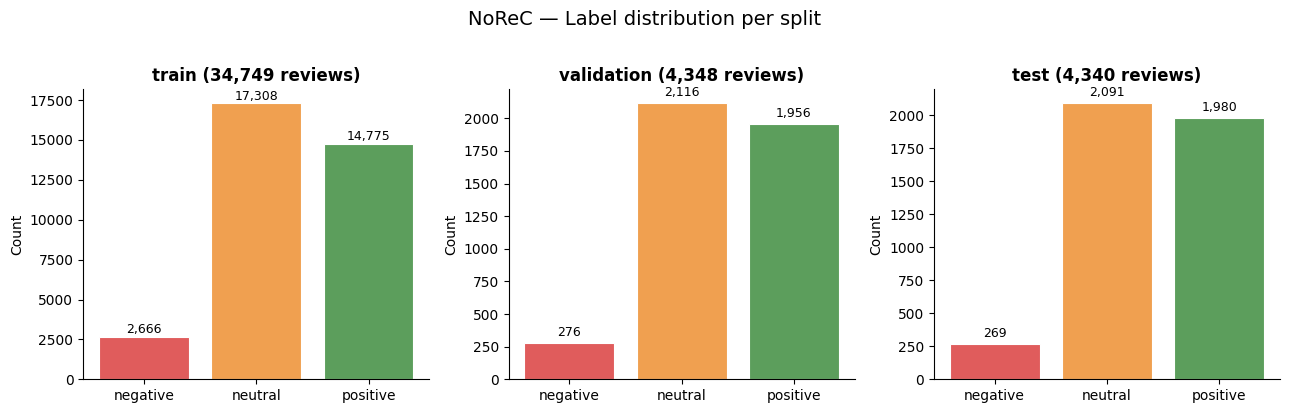

In [8]:
fig, axes = plt.subplots(1, 3, figsize=(13, 4), sharey=False)
colors = ["#e05c5c", "#f0a050", "#5c9e5c"]

for ax, split in zip(axes, ["train", "validation", "test"]):
    counts = [0, 0, 0]
    for lbl in raw_datasets[split]["label"]:
        counts[lbl] += 1
    bars = ax.bar(LABEL_NAMES, counts, color=colors, edgecolor="white", linewidth=0.8)
    ax.set_title(f"{split} ({sum(counts):,} reviews)", fontsize=12, fontweight="bold")
    ax.set_ylabel("Count")
    for bar, c in zip(bars, counts):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 30,
                f"{c:,}", ha="center", va="bottom", fontsize=9)
    ax.spines[["top", "right"]].set_visible(False)

fig.suptitle("NoReC — Label distribution per split", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

---
### *5 Tokenize*

In [ ]:
print(f"Loading tokenizer: {MODEL_NAME}")
tokenizer = AutoTokenizer.from_pretrained(MODEL_NAME)

def tokenize_fn(batch):
    return tokenizer(batch["text"], truncation=True, max_length=MAX_LENGTH, padding=False)

tokenized = raw_datasets.map(
    tokenize_fn,
    batched=True,
    remove_columns=["text", "doc_id"],
    desc="Tokenising",
)
tokenized.set_format("torch")

collator = DataCollatorWithPadding(tokenizer)

train_loader = DataLoader(tokenized["train"],      batch_size=BATCH_SIZE,      shuffle=True,  collate_fn=collator, num_workers=NUM_WORKERS)
val_loader   = DataLoader(tokenized["validation"], batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=NUM_WORKERS)
test_loader  = DataLoader(tokenized["test"],       batch_size=EVAL_BATCH_SIZE, shuffle=False, collate_fn=collator, num_workers=NUM_WORKERS)

print(f"Train batches: {len(train_loader)} | Val batches: {len(val_loader)} | Test batches: {len(test_loader)}")

Loading tokeniser: ltg/norbert3-small


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/951 [00:00<?, ?B/s]

The repository ltg/norbert3-small contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/ltg/norbert3-small .
 You can inspect the repository content at https://hf.co/ltg/norbert3-small.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


configuration_norbert.py: 0.00B [00:00, ?B/s]

...

special_tokens_map.json:   0%|          | 0.00/157 [00:00<?, ?B/s]

Tokenising:   0%|          | 0/34749 [00:00<?, ? examples/s]

Tokenising:   0%|          | 0/4348 [00:00<?, ? examples/s]

Tokenising:   0%|          | 0/4340 [00:00<?, ? examples/s]

Train batches: 2172 | Val batches: 136 | Test batches: 136


---
### *6 Load model*

In [10]:
print(f"Loading model: {MODEL_NAME}")
model = AutoModelForSequenceClassification.from_pretrained(
    MODEL_NAME,
    num_labels=3,
    id2label={i: l for i, l in enumerate(LABEL_NAMES)},
    label2id={l: i for i, l in enumerate(LABEL_NAMES)},
)
model.to(device)

total_params    = sum(p.numel() for p in model.parameters())
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"  Total params:     {total_params:,}")
print(f"  Trainable params: {trainable_params:,}")

Loading model: ltg/norbert3-small
The repository ltg/norbert3-small contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/ltg/norbert3-small .
 You can inspect the repository content at https://hf.co/ltg/norbert3-small.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository ltg/norbert3-small contains custom code which must be executed to correctly load the model. You can inspect the repository content at https://hf.co/ltg/norbert3-small .
 You can inspect the repository content at https://hf.co/ltg/norbert3-small.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


modeling_norbert.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/ltg/norbert3-small:
- modeling_norbert.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.


pytorch_model.bin:   0%|          | 0.00/188M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/124 [00:00<?, ?it/s]

NorbertForSequenceClassification LOAD REPORT from: ltg/norbert3-small
Key                             | Status  | 
--------------------------------+---------+-
head.nonlinearity.{1, 5}.weight | MISSING | 
head.nonlinearity.{1, 5}.bias   | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


  Total params:     40,635,267
  Trainable params: 40,635,267


---
### *7 Optimiser & scheduler*

In [11]:
optimizer    = AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=0.01)
total_steps  = len(train_loader) * EPOCHS
warmup_steps = int(total_steps * WARMUP_RATIO)
scheduler    = get_linear_schedule_with_warmup(
    optimizer, num_warmup_steps=warmup_steps, num_training_steps=total_steps
)

print(f"Total steps: {total_steps} | Warmup steps: {warmup_steps}")

Total steps: 8688 | Warmup steps: 868


---
### *8 Training loop*

Trains for `EPOCHS` epochs, evaluates on the validation set after each one, and saves the checkpoint with the best macro-F1.

In [ ]:
history = {"train_loss": [], "val_f1": []}
best_val_f1 = 0.0

for epoch in range(1, EPOCHS + 1):
    # ── Train ──────────────────────────────────────────────────────────────────
    model.train()
    total_loss = 0.0
    train_bar = tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [train]")

    for batch in train_bar:
        batch = {k: v.to(device) for k, v in batch.items()}
        outputs = model(**batch)
        loss = outputs.loss
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        scheduler.step()
        optimizer.zero_grad()
        total_loss += loss.item()
        train_bar.set_postfix(loss=f"{loss.item():.4f}")

    avg_loss = total_loss / len(train_loader)
    history["train_loss"].append(avg_loss)

    # ── Validate ───────────────────────────────────────────────────────────────
    model.eval()
    all_preds, all_labels = [], []

    with torch.no_grad():
        for batch in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [val]  ", leave=False):
            batch = {k: v.to(device) for k, v in batch.items()}
            preds = model(**batch).logits.argmax(dim=-1).cpu().numpy()
            all_preds.extend(preds)
            all_labels.extend(batch["labels"].cpu().numpy())

    val_f1 = f1_score(all_labels, all_preds, average="macro")
    history["val_f1"].append(val_f1)

    print(f"\nEpoch {epoch} | train_loss={avg_loss:.4f} | val_macro_f1={val_f1:.4f}")
    print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, digits=4))

    if val_f1 > best_val_f1:
        best_val_f1 = val_f1
        model.save_pretrained(BEST_MODEL_PATH)
        tokenizer.save_pretrained(BEST_MODEL_PATH)
        print(f"New best model saved (val_f1={best_val_f1:.4f})")

print(f"\nTraining complete. Best val macro-F1: {best_val_f1:.4f}")

Epoch 1/4 [train]:   0%|          | 0/2172 [00:00<?, ?it/s]

Epoch 1/4 [val]  :   0%|          | 0/136 [00:00<?, ?it/s]


Epoch 1 | train_loss=0.6876 | val_macro_f1=0.7129
              precision    recall  f1-score   support

    negative     0.7135    0.4783    0.5727       276
     neutral     0.7754    0.7571    0.7661      2116
    positive     0.7730    0.8287    0.7999      1956

    accuracy                         0.7716      4348
   macro avg     0.7540    0.6880    0.7129      4348
weighted avg     0.7704    0.7716    0.7690      4348



Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val_f1=0.7129)


...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

  ✓ New best model saved (val_f1=0.7394)


Epoch 4/4 [train]:   0%|          | 0/2172 [00:00<?, ?it/s]

Epoch 4/4 [val]  :   0%|          | 0/136 [00:00<?, ?it/s]


Epoch 4 | train_loss=0.2139 | val_macro_f1=0.7368
              precision    recall  f1-score   support

    negative     0.6737    0.5761    0.6211       276
     neutral     0.7831    0.7779    0.7805      2116
    positive     0.7980    0.8200    0.8089      1956

    accuracy                         0.7840      4348
   macro avg     0.7516    0.7247    0.7368      4348
weighted avg     0.7828    0.7840    0.7831      4348


Training complete. Best val macro-F1: 0.7394


### *8.1 Training curves*

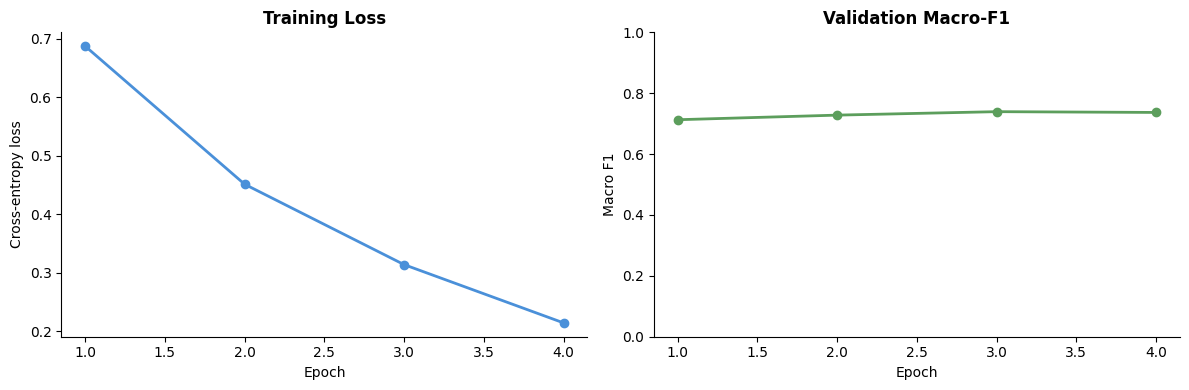

In [13]:
epochs_x = range(1, EPOCHS + 1)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

ax1.plot(epochs_x, history["train_loss"], marker="o", color="#4a90d9", linewidth=2)
ax1.set_title("Training Loss", fontweight="bold")
ax1.set_xlabel("Epoch")
ax1.set_ylabel("Cross-entropy loss")
ax1.spines[["top", "right"]].set_visible(False)

ax2.plot(epochs_x, history["val_f1"], marker="o", color="#5c9e5c", linewidth=2)
ax2.set_title("Validation Macro-F1", fontweight="bold")
ax2.set_xlabel("Epoch")
ax2.set_ylabel("Macro F1")
ax2.set_ylim(0, 1)
ax2.spines[["top", "right"]].set_visible(False)

plt.tight_layout()
plt.show()

---
### *9 Test set evaluation*

In [14]:
print("Loading best checkpoint ...")
model = AutoModelForSequenceClassification.from_pretrained(BEST_MODEL_PATH)
model.to(device)
model.eval()

all_preds, all_labels = [], []
with torch.no_grad():
    for batch in tqdm(test_loader, desc="Test"):
        batch = {k: v.to(device) for k, v in batch.items()}
        preds = model(**batch).logits.argmax(dim=-1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(batch["labels"].cpu().numpy())

test_f1 = f1_score(all_labels, all_preds, average="macro")
print(f"\nTest macro-F1: {test_f1:.4f}")
print(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, digits=4))

# Save results
with open(f"{OUTPUT_DIR}/test_results.txt", "w") as f:
    f.write(f"Model: {MODEL_NAME}\n")
    f.write(f"Best val macro_f1: {best_val_f1:.4f}\n")
    f.write(f"Test macro_f1:     {test_f1:.4f}\n\n")
    f.write(classification_report(all_labels, all_preds, target_names=LABEL_NAMES, digits=4))
print(f"Results saved to {OUTPUT_DIR}/test_results.txt")

Loading best checkpoint ...
The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

Test:   0%|          | 0/136 [00:00<?, ?it/s]


Test macro-F1: 0.7121
              precision    recall  f1-score   support

    negative     0.5895    0.5019    0.5422       269
     neutral     0.7839    0.7666    0.7751      2091
    positive     0.8020    0.8369    0.8191      1980

    accuracy                         0.7823      4340
   macro avg     0.7251    0.7018    0.7121      4340
weighted avg     0.7801    0.7823    0.7807      4340

Results saved to ./norec_sentiment_output/test_results.txt


---
### *10 Inference on new text*

Use the trained model to predict sentiment for any Norwegian text.

In [ ]:
def predict(text: str, model_path: str = BEST_MODEL_PATH) -> dict:
    """Predict sentiment for a Norwegian text string."""
    tok = AutoTokenizer.from_pretrained(model_path)
    mdl = AutoModelForSequenceClassification.from_pretrained(model_path)
    mdl.to(device)
    mdl.eval()

    inputs = tok(text, return_tensors="pt", truncation=True, max_length=MAX_LENGTH)
    inputs = {k: v.to(device) for k, v in inputs.items()}

    with torch.no_grad():
        logits = mdl(**inputs).logits

    probs = torch.softmax(logits, dim=-1).squeeze().tolist()
    pred_idx = int(torch.argmax(logits))
    return {
        "text": text[:80] + ("..." if len(text) > 80 else ""),
        "sentiment": LABEL_NAMES[pred_idx],
        "probabilities": {l: round(p, 4) for l, p in zip(LABEL_NAMES, probs)},
    }


# ── Example ─────────────────────────────────────────────────────────────────
examples = [
    "Fantastisk film! En av de beste jeg har sett på lenge. Imponerende skuespill.",
    "Ganske gjennomsnittlig. Ikke noe spesielt, men heller ikke direkte dårlig.",
    "Forferdelig opplevelse. Maten var kald og servicen var elendig.",
]

for text in examples:
    result = predict(text)
    label_emoji = {"positive": "🟢", "neutral": "🟡", "negative": "🔴"}
    print(f"{label_emoji[result['sentiment']]} [{result['sentiment'].upper():8s}]  {result['text']}")
    print(f"   Probs: { {k: f'{v:.3f}' for k, v in result['probabilities'].items()} }\n")

The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y


Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

🟢 [POSITIVE]  Fantastisk film! En av de beste jeg har sett på lenge. Imponerende skuespill.
   Probs: {'negative': '0.014', 'neutral': '0.064', 'positive': '0.922'}

The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you

Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

🟡 [NEUTRAL ]  Ganske gjennomsnittlig. Ikke noe spesielt, men heller ikke direkte dårlig.
   Probs: {'negative': '0.062', 'neutral': '0.920', 'positive': '0.018'}

The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wish to run the custom code? [y/N] y
The repository ./norec_sentiment_output/best_model contains custom code which must be executed to correctly load the model. You can inspect the repository content at /content/norec_sentiment_output/best_model .
 You can inspect the repository content at https://hf.co/./norec_sentiment_output/best_model.
You can avoid this prompt in future by passing the argument `trust_remote_code=True`.

Do you wi

Loading weights:   0%|          | 0/128 [00:00<?, ?it/s]

🔴 [NEGATIVE]  Forferdelig opplevelse. Maten var kald og servicen var elendig.
   Probs: {'negative': '0.471', 'neutral': '0.403', 'positive': '0.126'}



---
### *11 Upload to Hugging Face Hub*

Push fine-tuned model to the Hub so it can be reused later with `pipeline()`.

In [ ]:
from huggingface_hub import notebook_login
notebook_login()

HF_REPO = "malinhauglandh/norec-sentiment-norbert3-small"
model.push_to_hub(HF_REPO)
tokenizer.push_to_hub(HF_REPO)
print(f"Model pushed to https://huggingface.co/{HF_REPO}")

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Processing Files (0 / 0)      : |          |  0.00B /  0.00B            

New Data Upload               : |          |  0.00B /  0.00B            

  ...wy5cr08/model.safetensors:   0%|          |  552kB /  163MB            

README.md: 0.00B [00:00, ?B/s]

Model pushed to https://huggingface.co/malinhauglandh/norec-sentiment-norbert3-small
